In [1]:
import numpy as np
from numpy.fft import fft, ifft
import matplotlib.pyplot as plt
from scipy.sparse import diags, kron
from scipy.sparse.linalg import expm_multiply
from os.path import join, exists
from os import mkdir

In [2]:
IMG_DIR = "figures"
if not exists(IMG_DIR):
    mkdir(IMG_DIR)

## Scalar nonlinear hyperbolic PDE 

### Burgers' equation

In [66]:
M = 1
N = 256
N_p = N
h = 1/N
m = 10
omega = (m * h) ** (1/2)

In [67]:
x, p = np.meshgrid(np.linspace(0, 1, N), np.linspace(0, 1, N_p), indexing='ij')

In [68]:
mu = [0.3, 0.7]
sigma = [0.08, 0.05]
# u_0 = np.zeros_like(x)
# u_0 = u_0[np.newaxis,:]
# u_0[0] = np.exp(-0.5 * ((x - mu) / sigma) ** 2) / 1.1 #/ (sigma * np.sqrt(2 * np.pi))

In [93]:
u_0 = np.stack(
    [np.exp(-0.5 * ((x - mu[i]) / sigma[i]) ** 2) / 1.1 for i in range(M)]
    , axis=0)

# u_0 = np.stack([x * (1-x)], axis=0)
assert u_0.shape[0] == M

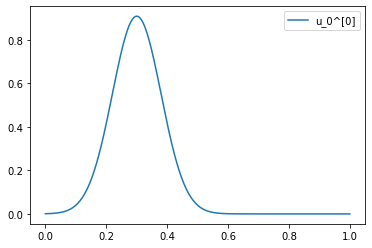

In [94]:
for i in range(M):
    plt.plot(x[:,0], u_0[i,:,0], label=f"u_0^[{i}]")

plt.legend()
plt.show()

In [95]:
psi_0 = np.zeros_like(x)

for i in range(M):
    psi_0 += delta_1d(p - u_0[i], omega)

psi_0 /= M

N_psi = np.linalg.norm(psi_0)
psi_0 /= N_psi

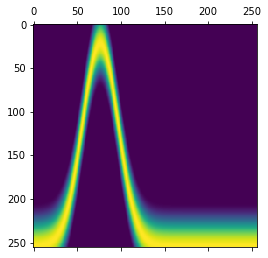

In [96]:
plt.matshow(np.rot90(psi_0))
plt.show()

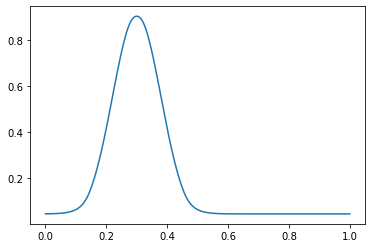

In [97]:
psi_tmp = np.copy(psi_0)
for i in range(N):
    psi_tmp[i] /= np.linalg.norm(psi_0[i])

plt.plot(x[:,0], np.sum(p * np.abs(psi_tmp) ** 2, axis=1))
plt.show()

In [98]:
discrete_gradient = diags([-np.ones(N-1), np.zeros(N), np.ones(N-1)], offsets=[-1,0,1])

In [99]:
discrete_gradient = discrete_gradient.tolil()

In [100]:
# periodic boundary conditions
discrete_gradient[0,N-1] = -1
discrete_gradient[N-1,0] = 1

discrete_gradient /= 2 * h

In [101]:
discrete_gradient_vec = np.zeros(N)

# second order central differences (flipped)
discrete_gradient_vec[1] = -1
discrete_gradient_vec[-1] = 1

discrete_gradient_vec /= 2 * h

evals = np.fft.fft(discrete_gradient_vec)

In [102]:
T = 0.3
N_t = 5 # time points

In [103]:
# %matplotlib

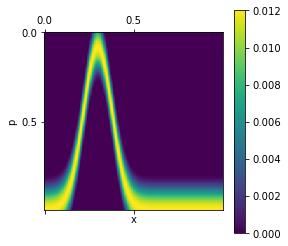

In [104]:
plt.matshow(np.rot90(psi_0))
# plt.title(f"t={t}")
plt.xlabel("x")
plt.xticks(np.arange(N, step=128), np.round(x[::128,0], decimals=2))
plt.ylabel("p")
plt.yticks(np.arange(N_p, step=128), np.round(p[0,::128], decimals=2))
plt.colorbar()
# plt.savefig(join(IMG_DIR, f"level_set_{t : 0.3f}.png"), dpi=100, facecolor="white")
plt.show()

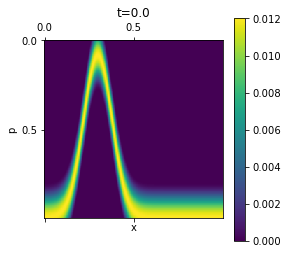

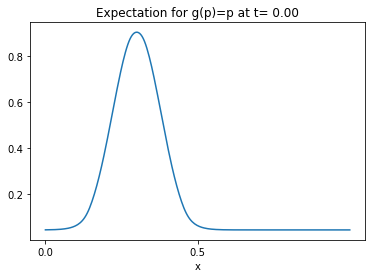

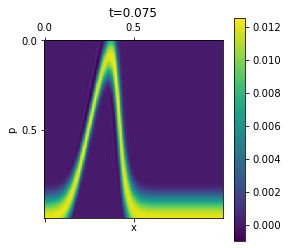

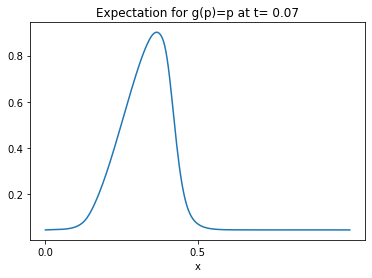

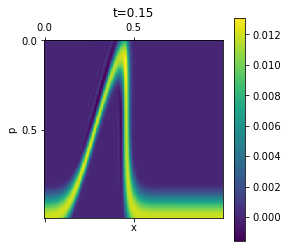

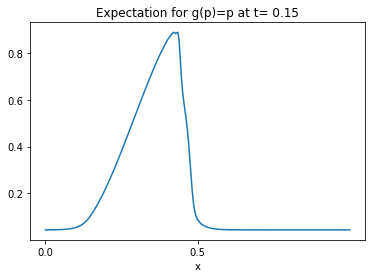

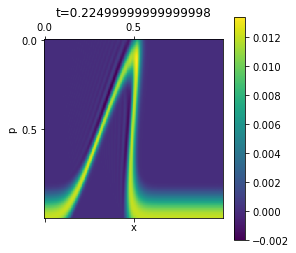

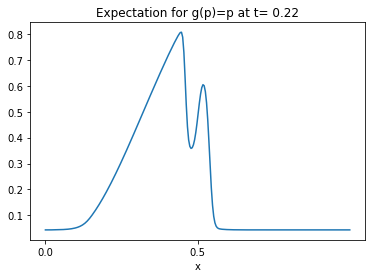

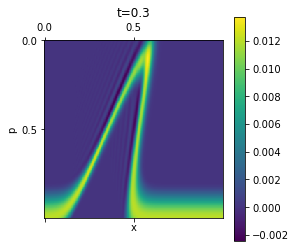

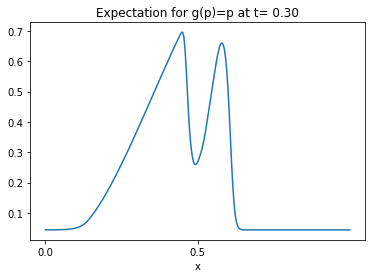

In [105]:
for t in np.linspace(0, T, N_t):
    psi = np.zeros_like(psi_0)
    for i,p_val in enumerate(np.linspace(0, 1, N_p)):

        psi[:,i] = ifft(np.exp(-(p_val) * t * evals) * fft(psi_0[:,i])).real
        # psi[:,i] = expm_multiply(-p_val * discrete_gradient * t, psi_0[:,i])
    plt.matshow(np.rot90(psi))
    plt.title(f"t={t}")
    plt.xlabel("x")
    plt.xticks(np.arange(N, step=128), np.round(x[::128,0], decimals=2))
    plt.ylabel("p")
    plt.yticks(np.arange(N_p, step=128), np.round(p[0,::128], decimals=2))
    plt.colorbar()
    plt.savefig(join(IMG_DIR, f"level_set_{t : 0.2f}.png"), dpi=100, facecolor="white")
    plt.show()

    psi_tmp = np.copy(psi)
    for i in range(N):
        psi_tmp[i] /= np.linalg.norm(psi[i])

    exp_g = np.sum(p * np.abs(psi_tmp) ** 2, axis=1)
    plt.plot(x[:,0], exp_g)
    plt.title(f"Expectation for g(p)=p at t={t : 0.2f}")
    plt.xlabel("x")
    plt.xticks(np.round(x[::128,0], decimals=2))
    plt.show()